## 3. Model Selection 

In this notebook we will look at different models and compare there performance. The purpose is to find out which model is suitable for going into more complex modelling. We will look into: 

- Random Guessing (no learning)
- Simple Artificial Neural Network
- Convolutional Neural Network

Since this is a image classification probelm, I highly assume that the CNN will perform better. The abillity to also know where pixel are located in relation to each other should give the CNN a big advantage.
I haven't implemented a majority class guessing benchmark, because of my decision of undersampling and balancing the classes. This would just give us the same benchmark as random guessing.

For our metrics we will look into accuracy and the F1 score. Since we dont have a multi-label classification, because each card can only have one rarity the hamming score is not a good fit. even though we are having a balanced dataset, the F1 score still adds useful information on top of accuracy. It tells us about precision an recall, so we can see if certain classes have better predictions or not.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
from data.dataset import Dataset
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
import matplotlib.pyplot as plt

from models.random_guessing_benchmark import RandomGuessingBenchmark
from evaluation.evaluation_metrics import EvaluationMetrics
from models.cnn_builder import CNNBuilder
from models.training_callbacks import default_callbacks 

/Users/markusgarmeister/Desktop/ML_PokeCard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3.1 Get and prepare Data

Here I load the data from disk and we first normalize the image arrays, in order to have smaller input values for the neural network, for better training. I also split the data into training, validation and test set. The data will be split in 70% training, 15% validation and 15% test data. 
- **Training Set**: Total samples 1750 / 350 per class
- **Validation Set**: Total samples 375 / 75 per class
- **Test Set**: Total samples 375 / 75 per class

In [2]:
dataset = Dataset()
X_train, X_val, X_test, y_train, y_val, y_test = dataset.get_train_val_test_split()

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Input shape: {X_train.shape[1:]}")
print(f"Number of classes: {y_train.shape[1]}")

Training set: 1750 samples
Validation set: 375 samples
Test set: 375 samples
Input shape: (168, 120, 3)
Number of classes: 5


## 3.2 Benchmark: Random Guessing

With our 5 balanced classes, random guessing should give ~20% accuracy. This benchmark should act as our lower bound and our model should be able to be better than that.


In [3]:
random_benchmark = RandomGuessingBenchmark()
y_pred_random = random_benchmark.predict(X_test)
eval_metrics = EvaluationMetrics(
    np.argmax(y_test, axis=1), np.argmax(y_pred_random, axis=1)
)
eval_metrics.print_eval_metrics()

Accuracy: 0.21866666666666668
F1 Score (Macro): 0.21812629901729394


## 3.3 Simple Artifical Neural Network (ANN)

The architecture of our ANN is very basic and its purpose is to check wether any neural network without spatial awareness is able to solve this problem.

Structure:
- **Input layer**: takes the image with shape (168 height x 120 width / RGB)
- **Flatten layer**: this turns the image (168x120x3) into a 1 dimensional vector of 60480 values. From this point on the model has no idea which pixels were originally next to each other.
- **Dense layer (128 neurons, ReLU)**: first hidden layer that learns combinations of pixel values.
- **Dense layer (64 neurons, ReLU)**: second hidden layer that learns more abstract combinations on top of the first one.
- **Output layer (5 neurons, Softmax)**: one neuron per rarity class. The output is a probability distribution over the 5 classes.

The model is compiled with the Adam optimizer and categorical corssentropy as loss function.

In [12]:
def build_simple_ann():
    model = Sequential([
        Input(shape=(168, 120, 3)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

simple_ann = build_simple_ann()
ann_history = simple_ann.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), callbacks=default_callbacks())
y_pred_ann = simple_ann.predict(X_test)
eval_metrics_ann = EvaluationMetrics(y_test, y_pred_ann)
eval_metrics_ann.print_eval_metrics()

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.2543 - loss: 56.9730 - val_accuracy: 0.3707 - val_loss: 16.3216 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.3760 - loss: 11.1102 - val_accuracy: 0.3333 - val_loss: 14.5650 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.3926 - loss: 10.5656 - val_accuracy: 0.4933 - val_loss: 5.9508 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.4149 - loss: 8.8109 - val_accuracy: 0.2480 - val_loss: 17.2550 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.4177 - loss: 11.9883 - val_accuracy: 0.4507 - val_loss: 7.8798 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.4577 - loss: 8.1554 - val_accuracy: 0.3627 - val_loss: 12.6037 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.4320 - loss: 8.

The result show us that the model has an accuracy of 54,9% and a F1 score of 55,4%. Thie means the predictions are balanced trough the classes and it performs much better than our random guessing benchmark.

## 3.4 Convolutional Neural Network (CNN)

The architecture of our CNN is the next step up from the ANN. Its purpose is to check whether spatial awareness actually helps with our image classification problem. Other tna our ANN, the CNN keeps the image as a 2D grid for as long as possible and only flattens it at the very end.

Structure:
- **Input layer**: takes the image with shape (168 height x 120 width / RGB).
- **Convolutional layer 1 (32 filters)**: 32 small filters slide across the image and learn to detect simple local patterns like edges, corners, and color transitions. The image stays 2D, so the model knows which pixels are next to each other.
- **Convolutional layer 2 (64 filters)**: 64 filters that build on top of the first layer and learn more complex patterns like textures, shapes, or holographic effects by combining the simple features from layer 1.
- **Flatten layer**: at this point the spatial information has already been used by the conv layers, so we can safely flatten the feature maps into a 1 dimensional vector to pass them into the dense layers.
- **Dense layer (128 neurons, ReLU)**: fully connected layer that combines all the learned features and prepares them for the final classification.
- **Output layer (5 neurons, Softmax)**: one neuron per rarity class. The output is a probability distribution over the 5 classes.

The model is compiled with the Adam optimizer and categorical crossentropy as loss function, same as the ANN.

In [13]:
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
cnn_model = builder.build_model()
cnn_history = cnn_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), callbacks=default_callbacks())
y_pred_cnn = cnn_model.predict(X_test)
eval_metrics_cnn = EvaluationMetrics(y_test, y_pred_cnn)
eval_metrics_cnn.print_eval_metrics()

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 209ms/step - accuracy: 0.3314 - loss: 3.8054 - val_accuracy: 0.4507 - val_loss: 1.2274 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.5291 - loss: 1.1310 - val_accuracy: 0.6027 - val_loss: 0.9957 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.6594 - loss: 0.8629 - val_accuracy: 0.6053 - val_loss: 0.9899 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.7109 - loss: 0.7587 - val_accuracy: 0.5680 - val_loss: 1.1065 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.8034 - loss: 0.5306 - val_accuracy: 0.6507 - val_loss: 1.1172 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.8343 - loss: 0.4471 - val_accuracy: 0.6560 - val_loss: 1.0766 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.9040 - loss: 0.2705 -

## 3.5 Comparison
As we can see and also expetced the CNN performs better then the ANN:

*CNN:*
- Accuracy: 74,9%
- F1 Score: 75,2 %

*ANN:*
- Accuracy: 54,9%
- F1 Score: 55,4 %

I assumed that the CNN would be better and this increase shows, that spatial structure matters for this problem.

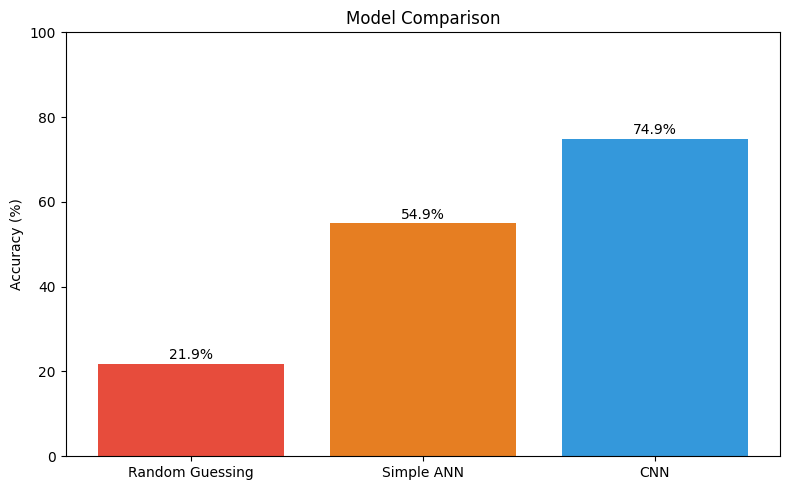

In [17]:
results = {
    "Random Guessing": eval_metrics.accuracy * 100,
    "Simple ANN": eval_metrics_ann.accuracy * 100,
    "CNN": eval_metrics_cnn.accuracy * 100
}

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#e67e22', '#3498db']
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')
plt.ylim(0, 100)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 1, f'{acc:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

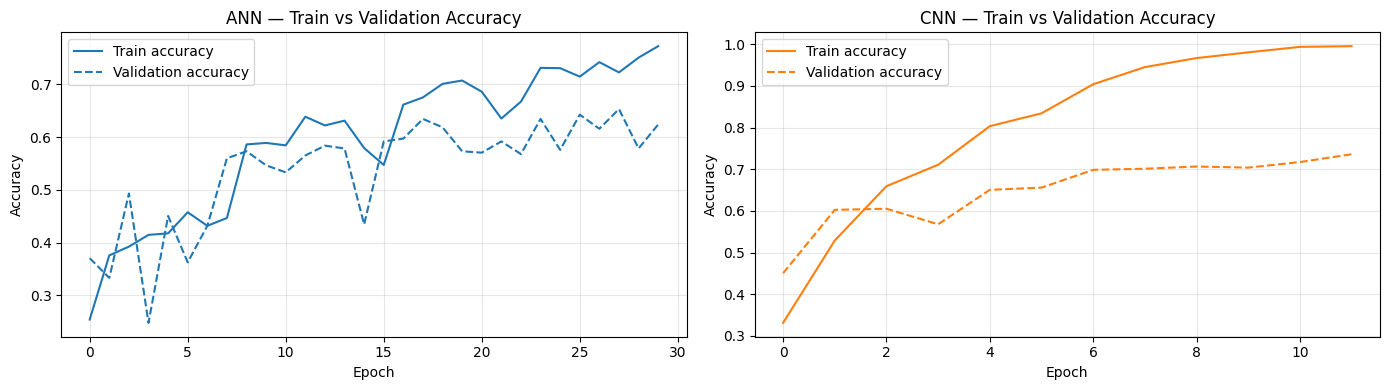

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ANN subplot
axes[0].plot(ann_history.history['accuracy'], label='Train accuracy', color='tab:blue')
axes[0].plot(ann_history.history['val_accuracy'], label='Validation accuracy', color='tab:blue', linestyle='--')
axes[0].set_title('ANN — Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# CNN subplot
axes[1].plot(cnn_history.history['accuracy'], label='Train accuracy', color='tab:orange')
axes[1].plot(cnn_history.history['val_accuracy'], label='Validation accuracy', color='tab:orange', linestyle='--')
axes[1].set_title('CNN — Train vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

From the plot above, we can see that the CNN hits nearly 100% accuracy on the training set and the validation set is at 74,9%. This gap signals some overfitting, so the model memorizes rather the cards from the training set instead of learning a pattern. Thats why the accuracy is so high. 

## 3.6 Summary

- *Random Guessing* -> **Accuracy: 21,9%  / F1 Score: 21,9%** 
- *ANN* -> **Accuracy: 54,9%  / F1 Score: 55,4%**
- *CNN* -> **Accuracy: 74,9%  / F1 Score: 75,2%**
- *Overfitting* -> the cnn has nearly 100% on the training set, while the validation set is at 74,9 % this gap indicates clear overfitting

The CNN is obviously the best model for our image classification problem. However as we can see it is overfitting, meaning it meorizes more the data. In the the next notebook we want to tackle overfitting, by applying soem regularizations.